# Partie 1 - Explorer les données

### 1. Charger les données CSV
#### Objectif
Charger le CSV dans `df`.
#### Pourquoi ?
Un DataFrame est le tableau de travail. `df` restera **brut** : les corrections se feront dans une copie.
#### Méthode
`pd.read_csv` avec un chemin relatif : le notebook est dans `notebooks/`, le CSV dans `../Data/`.
#### Code et résultat

In [76]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)   # ne pas tronquer les colonnes à l'affichage
sns.set_theme(style='whitegrid')             # style lisible pour tous les graphiques

CHEMIN_CSV = '../data/smart_building_raw.csv'   # remonter d'un dossier (..) puis entrer dans data/
df = pd.read_csv(CHEMIN_CSV)                    # lecture du fichier brut
print('Fichier lu :', CHEMIN_CSV)
print('Dimensions :', df.shape)

Fichier lu : ../data/smart_building_raw.csv
Dimensions : (507, 14)


#### Réponse / Interprétation
Le fichier est lu sans erreur : **507 lignes × 14 colonnes**. `df` reste brut pour toute la suite.

### 2. Afficher les premières lignes du dataset
#### Objectif
Afficher les cinq premières lignes.
#### Pourquoi ?
Vérifier visuellement que la lecture est correcte (séparateur, noms de colonnes, valeurs).
#### Méthode
Utiliser `head()` (5 lignes par défaut).
#### Code et résultat

In [29]:
df.head()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
0,1174,2025-02-13 06:00:00,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Normal,Jeudi,Non
1,1275,2025-03-10 12:00:00,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Normal,Lundi,Non
2,1493,2025-05-04 00:00:00,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Normal,Dimanche,Oui
3,1073,2025-01-19 00:00:00,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Normal,Dimanche,Non
4,1454,2025-04-24 06:00:00,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Normal,Jeudi,Non


#### Réponse / Interprétation
La lecture est correcte : les 14 colonnes sont bien séparées et nommées, avec un mélange de dates, de nombres et de textes. Rien d'anormal dans ces cinq lignes : les problèmes se lisent dans les statistiques (Q10).

### 3. Afficher les dernières lignes du dataset
#### Objectif
Afficher les cinq dernières lignes.
#### Pourquoi ?
Vérifier la fin du fichier (lignes tronquées, lignes parasites).
#### Méthode
Utiliser `tail()`.
#### Code et résultat

In [30]:
df.tail()

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
502,1107,2025-01-27 12:00:00,B2,École,C,29.8,66.5,778.0,48.0,243.5,Normal,Normal,Lundi,Non
503,1271,2025-03-09 12:00:00,B3,Hôpital,B,21.1,66.3,3900.0,53.0,145.8,Eco,Alerte,Dimanche,Oui
504,1349,2025-03-29 00:00:00,B5,Centre commercial,B,21.6,61.9,959.0,33.0,100.2,Eco,Normal,Samedi,Non
505,1436,2025-04-19 18:00:00,B7,Bureau,C,21.2,54.5,1066.0,38.0,150.9,Boost,Normal,Samedi,Oui
506,1103,2025-01-26 12:00:00,B2,École,D,NaN,64.8,584.0,29.0,163.4,Normal,Panne,Dimanche,Non


#### Réponse / Interprétation
La fin du fichier est propre (aucune ligne tronquée). On y repère déjà une température manquante (id 1103) et un CO₂ de 3 900 ppm (id 1271), très au-dessus des valeurs habituelles.

### 4. Combien d'observations contient le dataset ?
#### Objectif
Compter les lignes.
#### Pourquoi ?
Une ligne est une mesure d'un bâtiment à un instant.
#### Méthode
`df.shape[0]` : `shape` renvoie (lignes, colonnes).
#### Code et résultat

In [31]:
nb_observations = df.shape[0]
print(f'Le dataset contient {nb_observations} observations.')

Le dataset contient 507 observations.


#### Réponse / Interprétation
Le dataset contient **507 observations**. Ce chiffre comprend 7 lignes répétées : il y a en réalité 500 mesures distinctes (Q9 et Q14).

### 5. Combien de variables possède le dataset ?
#### Objectif
Compter les colonnes.
#### Pourquoi ?
Chaque colonne est une information mesurée ou décrite.
#### Méthode
`df.shape[1]`.

In [32]:
nb_variables = df.shape[1]
print(f'Le dataset possède {nb_variables} variables :')
print(df.columns.to_list())

Le dataset possède 14 variables :
['id_mesure', 'date', 'batiment', 'type_batiment', 'zone', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


#### Réponse / Interprétation
Le dataset possède **14 variables** : 1 identifiant, 1 date, 5 mesures numériques, 6 variables descriptives catégorielles et la cible `alerte`.

### 6. Identifier les variables numériques
#### Objectif
Lister les mesures numériques.
#### Pourquoi ?
Elles permettent les statistiques, la corrélation et la mise à l’échelle.
#### Méthode
`select_dtypes(include="number")`, puis retrait de l’identifiant `id_mesure` (voir Q9).
#### Code et résultat

In [33]:
# 1) ce que Pandas lit comme des nombres (dtype int ou float)
numeriques_dtype = df.select_dtypes(include='number').columns.tolist()
print('Colonnes de type numérique :', numeriques_dtype)

# 2) id_mesure est un entier, mais c'est un identifiant : on l'écarte des variables de mesure
variables_numeriques = [c for c in numeriques_dtype if c != 'id_mesure']
print('Variables numériques de mesure :', variables_numeriques)

Colonnes de type numérique : ['id_mesure', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']
Variables numériques de mesure : ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


#### Réponse / Interprétation
**5 variables numériques de mesure** : `temperature`, `humidite`, `co2`, `occupation`, `consommation_kwh`. `id_mesure` est lu comme un entier mais n'est pas une mesure : en calculer une moyenne n'aurait aucun sens.

### 7. Identifier les variables catégorielles
#### Objectif
Lister les colonnes textuelles qui décrivent une modalité.
#### Pourquoi ?
Elles seront encodées plus tard (Partie 4).
#### Méthode
Prendre les colonnes non numériques, sauf `date` (traitée à la question 8).
#### Code et résultat

In [34]:
# exclude='number' garde tout ce qui n'est pas numérique ; on retire 'date'
variables_categorielles = [c for c in df.select_dtypes(exclude='number').columns if c != 'date']
print('Variables catégorielles :', variables_categorielles)

# nombre de modalités BRUTES (avant nettoyage) de chaque variable
df[variables_categorielles].nunique().rename('modalités_brutes').to_frame()

Variables catégorielles : ['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


,modalités_brutes
batiment,8
type_batiment,16
zone,4
mode_climatisation,7
etat_systeme,3
jour_semaine,7
alerte,2


#### Réponse / Interprétation
**7 variables catégorielles** : `batiment`, `type_batiment`, `zone`, `mode_climatisation`, `etat_systeme`, `jour_semaine` et `alerte` (la cible). Ce sont des modalités, pas des quantités. Point d'attention : `type_batiment` compte 16 modalités brutes pour seulement 6 types réels, et `mode_climatisation` 7 pour 3 (traité en 12.g à 12.i).

### 8. Identifier les dates
#### Objectif
Vérifier que `date` est réellement temporelle.
#### Pourquoi ?
Le nom seul ne garantit pas le contenu : une colonne `date` peut contenir du texte invalide.
#### Méthode
Conversion avec `pd.to_datetime(..., format=..., errors='coerce')` : ce qui n'est pas une date valide devient `NaT`.
#### Code et résultat

In [35]:
FORMAT_DATE = '%Y-%m-%d %H:%M:%S'    # format observé dans le fichier (ex. 2025-02-13 06:00:00)
date_convertie = pd.to_datetime(df['date'], format=FORMAT_DATE, errors='coerce')

invalides = date_convertie.isna()    # True là où la conversion a échoué
print(f'{date_convertie.notna().sum()} dates valides sur {len(df)} ; {invalides.sum()} invalides')
print('Période couverte :', date_convertie.min(), '->', date_convertie.max())
df.loc[invalides, ['id_mesure', 'date']]

502 dates valides sur 507 ; 5 invalides
Période couverte : 2025-01-01 00:00:00 -> 2025-05-05 18:00:00


,id_mesure,date
107,1326,2025-02-30 08:00:00
182,1385,2025-13-45 10:00:00
285,1220,date_invalide
325,1045,31/99/2025
398,1217,2025-00-12


#### Réponse / Interprétation
`date` est bien temporelle : **502 dates sur 507** se convertissent (du 2025-01-01 au 2025-05-05). Les 5 autres sont invalides : jour impossible (30 février), mois 13 ou 00, autre format (`31/99/2025`) ou texte (`date_invalide`). On ne les supprime pas : elles sont traitées en 13.c.

### 9. Identifier les identifiants
#### Objectif
Tester l’unicité de `id_mesure`.
#### Pourquoi ?
Un identifiant doit être unique : une valeur répétée signale un doublon.
#### Méthode
Comparer le nombre de valeurs uniques au nombre de lignes, puis afficher les répétitions.
#### Code et résultat

In [36]:
print(f'{df.id_mesure.nunique()} valeurs uniques pour {len(df)} lignes ({df.id_mesure.duplicated().sum()} répétées)')
print('Plage des identifiants :', df.id_mesure.min(), '->', df.id_mesure.max())

# keep=False : afficher TOUTES les lignes concernées (l'original et sa copie)
df[df['id_mesure'].duplicated(keep=False)].sort_values('id_mesure')

500 valeurs uniques pour 507 lignes (7 répétées)
Plage des identifiants : 1001 -> 1500


,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
192,1026,2025-01-07 06:00:00,B6,BUREAU,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
117,1026,2025-01-07 06:00:00,B6,BUREAU,A,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
9,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
123,1118,2025-01-30 06:00:00,B1,Bureau,A,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
434,1264,2025-03-07 18:00:00,B1,Bureau,B,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
455,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
464,1320,2025-03-21 18:00:00,B7,Bureau,B,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
238,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
418,1402,2025-04-11 06:00:00,B2,École,A,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


#### Réponse / Interprétation
`id_mesure` est l'identifiant : **500 valeurs uniques** (de 1001 à 1500) pour 507 lignes. Les 7 répétitions sont des lignes affichées deux fois à l'identique (confirmé en Q14). Tant que ces doublons existent, la colonne n'est pas unique. Elle n'a aucun sens physique : elle sera exclue de X (Partie 2).

### 10. Déterminer les statistiques
#### Objectif
Calculer moyenne, médiane, minimum, maximum, écart-type et quartiles.
#### Pourquoi ?
Ils résument le centre et la dispersion ; les extrêmes révèlent les valeurs à contrôler.
#### Méthode
`describe()` sur les variables de mesure, transposé (une ligne par variable) et renommé en français.
#### Code et résultat

In [37]:
stats = df[variables_numeriques].describe().T.rename(columns={
    'count': 'effectif', 'mean': 'moyenne', 'std': 'écart-type', 'min': 'minimum',
    '25%': 'Q1', '50%': 'médiane', '75%': 'Q3', 'max': 'maximum'})
stats.round(2)

,effectif,moyenne,écart-type,minimum,Q1,médiane,Q3,maximum
temperature,495.0,24.15,7.42,-30.0,21.60,24.00,26.00,96.0
humidite,496.0,57.86,16.03,-12.0,49.28,57.55,65.75,160.0
co2,500.0,844.15,582.18,89.0,623.75,787.50,952.00,6000.0
occupation,501.0,44.85,24.95,-20.0,27.00,46.00,61.00,116.0
consommation_kwh,502.0,169.07,53.16,-100.0,136.88,169.80,202.98,336.2


#### Réponse / Interprétation
Le cœur des données est sain (les quartiles Q1–Q3 sont resserrés et plausibles), mais les **extrêmes sont impossibles** : température de −30 à 96 °C, humidité de −12 à 160 %, occupation de −20 à 116, consommation de −100 à 336 kWh. Le CO₂ monte à 6 000 ppm pour une médiane de 788 : son écart-type (582) est énorme par rapport à sa moyenne (844), signe de valeurs extrêmes.

### 11. Y a-t-il des variables potentiellement problématiques ?
#### Objectif
Distinguer les constats (chiffrés) des vérifications à faire.
#### Pourquoi ?
Un signal ne justifie pas une correction arbitraire : on constate d’abord, on vérifie ensuite (Q12).
#### Méthode
Synthétiser des indicateurs **calculés** (jamais écrits à la main) : manquantes, extrêmes, modalités.
#### Code et résultat

In [38]:
# a) valeurs manquantes par colonne (données brutes)
print('Valeurs manquantes (brut) :')
print(df.isna().sum()[lambda s: s > 0].to_dict())

# b) dates et identifiants
print('\nDates invalides :', date_convertie.isna().sum(), '| id_mesure répétés :', df.id_mesure.duplicated().sum())

# c) modalités avant -> après strip + lower : révèle les écritures hétérogènes
print('\nModalités par variable catégorielle (brut -> après strip+lower) :')
for c in variables_categorielles:
    print(f'  {c:20s} {df[c].nunique():2d} -> {df[c].str.strip().str.lower().nunique():2d}')

# d) extrêmes des variables numériques
df[variables_numeriques].agg(['min', 'max']).T

Valeurs manquantes (brut) :
{'type_batiment': 4, 'temperature': 12, 'humidite': 11, 'co2': 7, 'occupation': 6, 'consommation_kwh': 5, 'mode_climatisation': 5, 'jour_semaine': 5}

Dates invalides : 5 | id_mesure répétés : 7

Modalités par variable catégorielle (brut -> après strip+lower) :
  batiment              8 ->  8
  type_batiment        16 ->  9
  zone                  4 ->  4
  mode_climatisation    7 ->  4
  etat_systeme          3 ->  3
  jour_semaine          7 ->  7
  alerte                2 ->  2


,min,max
temperature,-30.0,96.0
humidite,-12.0,160.0
co2,89.0,6000.0
occupation,-20.0,116.0
consommation_kwh,-100.0,336.2


#### Réponse / Interprétation
Oui, cinq familles de problèmes, chacune vérifiée ensuite :
- **Valeurs impossibles** dans `temperature`, `humidite`, `occupation` et `consommation_kwh` (minimums négatifs, maximums absurdes) → Q12.
- **Extrêmes de CO₂** (jusqu'à 6 000 ppm) : pas forcément impossibles, à arbitrer en Q15–16.
- **Valeurs manquantes** dans 8 colonnes (de 4 à 12 valeurs) → Q13.
- **5 dates invalides et 7 identifiants répétés** → Q13 et Q14.
- **Catégories hétérogènes** : `type_batiment` passe de 16 à 9 modalités après `strip` + `lower`, `mode_climatisation` de 7 à 4. Il reste donc des fautes que ce nettoyage de base ne règle pas → Q12.g à 12.j.

### 12. Rechercher les données incohérentes
 on **détecte** d'abord (a–e), on **corrige** ensuite (f–j). Seules les erreurs manifestes deviennent `NaN`, dans une copie `df_nettoye` ; `df` reste brut.

#### 12.a. Humidité < 0
#### Objectif
Repérer les humidités négatives.
#### Pourquoi ?
Une humidité relative est un pourcentage : elle ne peut pas être négative.
#### Méthode
Masque booléen `df.humidite < 0`.
#### Code et résultat

In [39]:
masque_hum_neg = df['humidite'] < 0
print('Humidités négatives :', masque_hum_neg.sum())
df.loc[masque_hum_neg, ['id_mesure', 'batiment', 'humidite']]

Humidités négatives : 3


,id_mesure,batiment,humidite
281,1126,B2,-5.0
335,1036,B4,-8.0
366,1216,B3,-12.0


#### Réponse / Interprétation
**3 humidités négatives** (−5, −8 et −12 %) : impossibles, une humidité relative est un pourcentage.

#### 12.b. Humidité > 100
#### Objectif
Repérer les humidités supérieures à 100 %.
#### Pourquoi ?
Une humidité relative ne dépasse pas 100 %.
#### Méthode
Masque booléen `df.humidite > 100`.
#### Code et résultat

In [40]:
masque_hum_sup = df['humidite'] > 100
print('Humidités > 100 :', masque_hum_sup.sum())
df.loc[masque_hum_sup, ['id_mesure', 'batiment', 'humidite']].sort_values('humidite')

Humidités > 100 : 7


,id_mesure,batiment,humidite
59,1246,B5,108.0
342,1096,B8,110.0
160,1186,B8,125.0
327,1066,B2,132.0
268,1276,B1,140.0
103,1016,B6,145.0
128,1156,B1,160.0


#### Réponse / Interprétation
**7 humidités supérieures à 100 %** (de 108 à 160 %) : impossibles pour une humidité relative.

#### 12.c. Température extrêmement élevée
#### Objectif
Repérer les températures aberrantes vers le haut.
#### Pourquoi ?
Un capteur intérieur ne mesure pas 88 °C : il faut un seuil justifié, pas un seuil arbitraire.
#### Méthode
Règle de Tukey (Q3 + 1,5 × IQR) pour repérer les candidats, puis regard sur l'écart entre valeurs plausibles et extrêmes.
#### Code et résultat

In [41]:
q1, q3 = df['temperature'].quantile([0.25, 0.75])
seuil_iqr = q3 + 1.5 * (q3 - q1)                # au-delà : valeur atypique (signal, pas verdict)
print(f'Seuil IQR haut : {seuil_iqr:.1f} °C')
display(df.loc[df['temperature'] > seuil_iqr, ['id_mesure', 'batiment', 'temperature']].sort_values('temperature'))

# Seuil retenu : borne physique plausible d'un capteur intérieur
TEMP_MIN, TEMP_MAX = 0, 50
masque_temp_haute = df['temperature'] > TEMP_MAX
print(f'Plus haute valeur plausible : {df.loc[~masque_temp_haute, "temperature"].max()} °C | '
      f'plus basse valeur extrême : {df.loc[masque_temp_haute, "temperature"].min()} °C')
print('Températures > ', TEMP_MAX, '°C :', masque_temp_haute.sum())

Seuil IQR haut : 32.6 °C


,id_mesure,batiment,temperature
157,1361,B3,34.2
7,1141,B2,72.5
161,1061,B5,88.0
499,1021,B2,95.2
116,1181,B6,96.0


Plus haute valeur plausible : 34.2 °C | plus basse valeur extrême : 72.5 °C
Températures >  50 °C : 4


#### Réponse / Interprétation
Le seuil IQR (32,6 °C) signale 5 valeurs, mais elles forment **deux groupes très distincts** : 34,2 °C reste plausible (un local chaud), tandis que 72,5 / 88 / 95,2 / 96 °C sont impossibles dans un bâtiment. Il n'existe aucune mesure entre 34,2 et 72,5 °C. Le seuil physique de **50 °C** sépare proprement les deux : **4 valeurs erronées**, alors que l'IQR seul aurait aussi éliminé 34,2 °C à tort.

#### 12.d. Valeurs négatives
#### Objectif
Chercher les valeurs négatives dans **toutes** les mesures.
#### Pourquoi ?
Température mise à part, une humidité, un CO₂, une occupation ou une consommation négatifs sont impossibles.
#### Méthode
Un masque `< 0` par variable, comptage, puis affichage des cas restants (température, occupation).
#### Code et résultat

In [42]:
negatifs = {v: df[v] < 0 for v in variables_numeriques}      # un masque par variable
print('Valeurs négatives par variable :', {v: int(m.sum()) for v, m in negatifs.items()})
print('Occupation > 100 (à surveiller, non impossible) :', int((df['occupation'] > 100).sum()))
df.loc[negatifs['temperature'] | negatifs['occupation'], ['id_mesure', 'temperature', 'occupation']]

Valeurs négatives par variable : {'temperature': 2, 'humidite': 3, 'co2': 0, 'occupation': 5, 'consommation_kwh': 4}
Occupation > 100 (à surveiller, non impossible) : 10


,id_mesure,temperature,occupation
22,1031,26.1,-5.0
185,1221,-25.0,34.0
358,1101,-30.0,43.0
376,1231,19.0,-8.0
430,1081,23.5,-12.0
487,1131,26.3,-2.0
494,1331,22.7,-20.0


#### Réponse / Interprétation
Aucun CO₂ négatif. En revanche : **2 températures négatives** (−25 et −30 °C, impossibles dans un bâtiment) et **5 occupations négatives** (de −20 à −2, un nombre de personnes ne peut pas être négatif), en plus des 3 humidités et 4 consommations déjà vues. À part : 10 occupations dépassent 100 (de 101 à 116). Elles ne sont **pas impossibles** (l'occupation est un nombre de personnes, sans plafond à 100) : elles relèvent de la stratégie des valeurs aberrantes (Q16), pas d'une correction.

#### 12.e. Consommation négative
#### Objectif
Repérer les consommations négatives.
#### Pourquoi ?
Un bâtiment consomme de l’énergie, il n’en produit pas ici : une consommation négative est une erreur.
#### Méthode
Masque booléen `consommation_kwh < 0`.
#### Code et résultat

In [43]:
masque_conso_neg = df['consommation_kwh'] < 0
print('Consommations négatives :', masque_conso_neg.sum())
df.loc[masque_conso_neg, ['id_mesure', 'batiment', 'consommation_kwh']]

Consommations négatives : 4


,id_mesure,batiment,consommation_kwh
59,1246,B5,-15.0
154,1046,B2,-50.0
199,1146,B7,-20.0
441,1346,B5,-100.0


#### Réponse / Interprétation
**4 consommations négatives** (−15, −20, −50 et −100 kWh). Un bâtiment consomme de l'énergie et n'en produit pas ici : ce sont des erreurs de capteur.

#### 12.f. Transformer les valeurs erronées en valeurs manquantes
#### Objectif
Mettre `NaN` là où la valeur est manifestement fausse et irrécupérable.
#### Pourquoi ?
On ne peut pas deviner qu'une humidité de 160 % valait 60 % : inventer une valeur fausserait le modèle. `NaN` est honnête et sera imputé proprement plus tard.
#### Méthode
Copie `df_nettoye`, un masque par colonne, `NaN` sur les cas identifiés, conversion de `date` (invalides -> `NaT`) et journal des corrections.
#### Code et résultat

In [44]:
df_nettoye = df.copy()      # copie de travail : df reste le brut, intact

masques = {
    'temperature':      masque_temp_haute | negatifs['temperature'],
    'humidite':         masque_hum_neg | masque_hum_sup,
    'occupation':       negatifs['occupation'],
    'consommation_kwh': masque_conso_neg,
}
for colonne, m in masques.items():
    df_nettoye.loc[m, colonne] = np.nan

df_nettoye['date'] = date_convertie          # texte -> datetime ; les 5 dates invalides deviennent NaT

# journal : quelle valeur brute a été remplacée, où (traçabilité)
journal = pd.concat([
    pd.DataFrame({'id_mesure': df.loc[m, 'id_mesure'], 'colonne': col, 'valeur_brute': df.loc[m, col]})
    for col, m in masques.items()])
print('Corrections (valeur -> NaN) par colonne :')
print(journal.groupby('colonne').size().to_dict(), '| dates invalides -> NaT :', int(invalides.sum()))
print('Total de valeurs remplacées :', len(journal))

Corrections (valeur -> NaN) par colonne :
{'consommation_kwh': 4, 'humidite': 10, 'occupation': 5, 'temperature': 6} | dates invalides -> NaT : 5
Total de valeurs remplacées : 25


#### Réponse / Interprétation
**25 valeurs** remplacées par `NaN` : 10 humidités (3 + 7), 6 températures (2 + 4), 5 occupations et 4 consommations. Les 5 dates invalides deviennent `NaT` (elles sont récupérées en 13.c). Aucune ligne n'est supprimée : elles gardent leurs autres mesures valides. Le `journal` conserve chaque valeur brute remplacée, et `df` reste intact.

#### 12.g. Catégories mal orthographiées
#### Objectif
Repérer les écritures différentes d’une même modalité.
#### Pourquoi ?
Sans nettoyage, « Bureau », « BUREAU » et « Bureu » deviendraient 3 colonnes distinctes après encodage.
#### Méthode
Lister les modalités brutes de chaque variable catégorielle ; `repr` (guillemets Python) révèle les espaces parasites.
#### Code et résultat

In [45]:
for c in variables_categorielles:
    valeurs = sorted(df[c].dropna().unique(), key=str)
    print(f'{c:20s} ({len(valeurs):2d})', valeurs)

batiment             ( 8) ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8']
type_batiment        (16) [' Bureau ', ' UNIVERSITÉ', 'BUREAU', 'Bureau', 'Bureu', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'bureau', 'centre commercial', 'ecole', 'entrepot', 'hôpital ', 'ÉCOLE', 'École']
zone                 ( 4) ['A', 'B', 'C', 'D']
mode_climatisation   ( 7) ['BOOST', 'Boost', 'Eco', 'Normal', 'Normal ', 'normal', 'normale']
etat_systeme         ( 3) ['Alerte', 'Normal', 'Panne']
jour_semaine         ( 7) ['Dimanche', 'Jeudi', 'Lundi', 'Mardi', 'Mercredi', 'Samedi', 'Vendredi']
alerte               ( 2) ['Non', 'Oui']


#### Réponse / Interprétation
Deux variables seulement sont concernées. `type_batiment` : **16 écritures pour 6 types** (` Bureau `, `BUREAU`, `bureau`, `Bureu`, `ecole`, `ÉCOLE`, `entrepot`, `hôpital `…). `mode_climatisation` : **7 écritures pour 3 modes** (`BOOST`, `Normal `, `normale`…). Les autres variables sont propres. Trois types de défauts : espaces parasites, casse, et vraies fautes (`Bureu`, `normale`, accents manquants dans `ecole` et `entrepot`).

#### 12.h. Normaliser les catégories textuelles
#### Objectif
Supprimer les espaces puis uniformiser la casse.
#### Pourquoi ?
Regrouper les variantes triviales (espaces, majuscules) sans toucher au sens.
#### Méthode
`str.strip()` puis `str.lower()` sur toutes les variables catégorielles de `df_nettoye`.
#### Code et résultat

In [46]:
for c in variables_categorielles:
    df_nettoye[c] = df_nettoye[c].str.strip().str.lower()     # les NaN restent NaN

for c in ['type_batiment', 'mode_climatisation']:
    print(f'{c:20s}', sorted(df_nettoye[c].dropna().unique()))

type_batiment        ['bureau', 'bureu', 'centre commercial', 'ecole', 'entrepot', 'entrepôt', 'hôpital', 'université', 'école']
mode_climatisation   ['boost', 'eco', 'normal', 'normale']


#### Réponse / Interprétation
Après `strip` + `lower`, `type_batiment` passe de 16 à **9 modalités** et `mode_climatisation` de 7 à **4**. Les espaces et la casse sont réglés, mais il reste 4 vraies fautes que cette étape ne peut pas corriger : `bureu`, `ecole` (face à `école`), `entrepot` (face à `entrepôt`) et `normale`.

#### 12.i. Fautes résiduelles (complément)
#### Objectif
Corriger les fautes que `strip` + `lower` ne peuvent pas régler.
#### Pourquoi ?
« bureu », « ecole » (sans accent), « entrepot » et « normale » sont des fautes de frappe **sans ambiguïté** : la vraie valeur est retrouvable, donc on corrige au lieu de mettre `NaN`.
#### Méthode
Petit dictionnaire de corrections, appliqué avec `replace`.
#### Code et résultat

In [47]:
corrections_orthographe = {'bureu': 'bureau', 'ecole': 'école', 'entrepot': 'entrepôt', 'normale': 'normal'}
df_nettoye[variables_categorielles] = df_nettoye[variables_categorielles].replace(corrections_orthographe)

for c in ['type_batiment', 'mode_climatisation']:
    print(f'{c:20s}', sorted(df_nettoye[c].dropna().unique()))

type_batiment        ['bureau', 'centre commercial', 'entrepôt', 'hôpital', 'université', 'école']
mode_climatisation   ['boost', 'eco', 'normal']


#### Réponse / Interprétation
Il reste **6 types** (`bureau`, `centre commercial`, `entrepôt`, `hôpital`, `université`, `école`) et **3 modes** (`boost`, `eco`, `normal`). Ces corrections sont sûres : chaque faute n'a qu'une seule lecture possible. C'est une décision différente de 12.f : ici la vraie valeur est **retrouvable**, donc on la rétablit au lieu de créer un `NaN`.

#### 12.j. Cohérence entre `batiment` et `type_batiment` (complément)
#### Objectif
Vérifier qu’un même bâtiment n’a qu’un seul type.
#### Pourquoi ?
Un bâtiment (B1…B8) a un seul type. Toute ligne qui le contredit est une incohérence.
#### Méthode
Tableau croisé, type majoritaire par bâtiment, liste des lignes qui s'en écartent, puis test : ces lignes sont-elles écrites proprement dans le brut ?
#### Code et résultat

In [48]:
repartition = pd.crosstab(df_nettoye['batiment'], df_nettoye['type_batiment'])
display(repartition)

type_attendu = repartition.idxmax(axis=1)                 # type majoritaire de chaque bâtiment
attendu = df_nettoye['batiment'].map(type_attendu)
incoherent = df_nettoye['type_batiment'].notna() & (df_nettoye['type_batiment'] != attendu)

display(pd.DataFrame({'id_mesure': df.loc[incoherent, 'id_mesure'], 'batiment': df.loc[incoherent, 'batiment'],
                      'type_brut': df.loc[incoherent, 'type_batiment'], 'type_attendu': attendu[incoherent]}))

# Test : ces lignes incohérentes sont-elles écrites sous une forme « propre » dans le brut ?
formes_propres = df['type_batiment'].value_counts().loc[lambda s: s >= 40].index
print('Lignes incohérentes :', incoherent.sum(),
      '| dont écrites proprement dans le brut :', df.loc[incoherent, 'type_batiment'].isin(formes_propres).sum())

df_nettoye.loc[incoherent, 'type_batiment'] = attendu[incoherent]      # correction déterministe
print('Corrigées à partir de batiment :', incoherent.sum())

type_batiment,bureau,centre commercial,entrepôt,hôpital,université,école
batiment,,,,,,
b1,91,0,1,1,0,0
b2,1,0,0,0,0,60
b3,0,0,0,58,0,0
b4,56,0,0,0,0,0
b5,0,65,0,0,1,0
b6,2,1,0,0,48,1
b7,65,0,0,0,0,0
b8,0,0,52,0,0,0


,id_mesure,batiment,type_brut,type_attendu
61,1056,B6,ecole,université
117,1026,B6,BUREAU,université
192,1026,B6,BUREAU,université
246,1011,B2,bureau,école
311,1116,B5,UNIVERSITÉ,centre commercial
329,1086,B1,hôpital,bureau
358,1101,B6,centre commercial,université
487,1131,B1,entrepot,bureau


Lignes incohérentes : 8 | dont écrites proprement dans le brut : 0
Corrigées à partir de batiment : 8


#### Réponse / Interprétation
Chaque bâtiment a un type dominant très net (B3 est « hôpital » sur 58 lignes sur 58), mais **8 lignes le contredisent** (7 mesures : l'id 1026 est en double). Par exemple B6, « université » sur 48 lignes, est noté « bureau » sur 2 lignes.

**C'est `type_batiment` qui est faux, pas `batiment`** : aucune de ces 8 lignes n'est écrite proprement dans le brut (toutes ont une casse, un espace ou un accent anormal : `BUREAU`, `hôpital `, `entrepot`…), alors qu'aucune ligne écrite proprement ne contredit son bâtiment. La vraie valeur est donc retrouvable à partir de `batiment` et les 8 lignes sont corrigées. Hypothèse retenue : un bâtiment a un seul type.

### 13. Rechercher et traiter les valeurs manquantes
État de `df_nettoye` après la question 12 : les valeurs erronées y sont déjà devenues `NaN`.

#### 13.a. Nombre et pourcentage de valeurs manquantes par colonne
#### Objectif
Quantifier les manquantes.
#### Pourquoi ?
Savoir où et combien avant de choisir une stratégie.
#### Méthode
`isna().sum()` et division par le nombre de lignes.
#### Code et résultat

In [49]:
manquantes = df_nettoye.isna().sum()
tableau_na = pd.DataFrame({'nb_manquantes': manquantes, 'pct': (manquantes / len(df_nettoye) * 100).round(2)})
tableau_na = tableau_na.sort_values('nb_manquantes', ascending=False)
tableau_na[tableau_na.nb_manquantes > 0]

,nb_manquantes,pct
humidite,21,4.14
temperature,18,3.55
occupation,11,2.17
consommation_kwh,9,1.78
co2,7,1.38
date,5,0.99
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79


#### Réponse / Interprétation
9 colonnes ont des valeurs manquantes, toutes **sous 5 %** : `humidite` (21, soit 4,14 %), `temperature` (18, 3,55 %), `occupation` (11), `consommation_kwh` (9), `co2` (7), puis `date`, `mode_climatisation` et `jour_semaine` (5 chacune) et `type_batiment` (4). Une part vient de la question 12 : les valeurs impossibles converties en `NaN` s'ajoutent aux manquantes d'origine.

#### 13.b. Quelle variable possède le plus de valeurs manquantes ?
#### Objectif
Identifier la variable la plus touchée.
#### Pourquoi ?
Elle demande le plus d’attention.
#### Méthode
`idxmax()` sur le tableau précédent.
#### Code et résultat

In [50]:
pire = tableau_na['nb_manquantes'].idxmax()
print(f"Variable la plus touchée : {pire} ({tableau_na.loc[pire, 'nb_manquantes']} valeurs, {tableau_na.loc[pire, 'pct']} %)")

Variable la plus touchée : humidite (21 valeurs, 4.14 %)


#### Réponse / Interprétation
**`humidite`** : 21 valeurs manquantes (4,14 %), dont 11 manquantes d'origine et 10 valeurs impossibles converties en `NaN` (12.f).

#### 13.c. Quelle stratégie pour les valeurs manquantes ?
#### Objectif
Choisir un traitement adapté à chaque cas.
#### Pourquoi ?
Toutes les manquantes ne se traitent pas pareil : certaines se **déduisent** d'une autre colonne (aucun risque), d'autres doivent être **estimées** (risque de fuite de données si on le fait avant le découpage).
#### Méthode
1) reconstruire ce qui est déterministe (`date` depuis `id_mesure`, `jour_semaine` depuis `date`, `type_batiment` depuis `batiment`) ; 2) laisser le reste à l'imputation du pipeline (Partie 6).
#### Code et résultat

In [51]:
# 0) date : id_mesure suit l'ordre chronologique, avec un pas de 6 h par identifiant
debut, id0 = df_nettoye['date'].min(), df_nettoye['id_mesure'].min()
date_depuis_id = debut + pd.to_timedelta((df_nettoye['id_mesure'] - id0) * 6, unit='h')
valides = df_nettoye['date'].notna()
print('Règle « date = début + 6 h × (id - id_min) » exacte sur',
      (df_nettoye.loc[valides, 'date'] == date_depuis_id[valides]).sum(), '/', valides.sum(), 'lignes valides')
avant_date = df_nettoye['date'].isna().sum()
df_nettoye['date'] = df_nettoye['date'].fillna(date_depuis_id)      # on ne remplit QUE les NaT

# 1) jour_semaine : se déduit de la date (maintenant complète)
jours = dict(enumerate(['lundi', 'mardi', 'mercredi', 'jeudi', 'vendredi', 'samedi', 'dimanche']))
jour_calcule = df_nettoye['date'].dt.dayofweek.map(jours)
comparables = df_nettoye['jour_semaine'].notna()
print('Cohérence jour_semaine / date sur les lignes renseignées :',
      (df_nettoye.loc[comparables, 'jour_semaine'] == jour_calcule[comparables]).mean())
avant_jour = df_nettoye['jour_semaine'].isna().sum()
df_nettoye['jour_semaine'] = df_nettoye['jour_semaine'].fillna(jour_calcule)

# 2) type_batiment : chaque bâtiment a un seul type (12.j) -> on le relit depuis batiment
avant_type = df_nettoye['type_batiment'].isna().sum()
df_nettoye['type_batiment'] = df_nettoye['type_batiment'].fillna(df_nettoye['batiment'].map(type_attendu))

print(f"date          : {avant_date} manquantes -> {df_nettoye['date'].isna().sum()}")
print(f"jour_semaine  : {avant_jour} manquantes -> {df_nettoye['jour_semaine'].isna().sum()}")
print(f"type_batiment : {avant_type} manquantes -> {df_nettoye['type_batiment'].isna().sum()}")
print('\nManquantes restantes (à imputer dans le pipeline, sur le train uniquement) :')
print(df_nettoye.isna().sum()[lambda s: s > 0].to_dict())

Règle « date = début + 6 h × (id - id_min) » exacte sur 502 / 502 lignes valides
Cohérence jour_semaine / date sur les lignes renseignées : 1.0
date          : 5 manquantes -> 0
jour_semaine  : 5 manquantes -> 0
type_batiment : 4 manquantes -> 0

Manquantes restantes (à imputer dans le pipeline, sur le train uniquement) :
{'temperature': 18, 'humidite': 21, 'co2': 7, 'occupation': 11, 'consommation_kwh': 9, 'mode_climatisation': 5}


#### Réponse / Interprétation
Stratégie en deux temps.

**1. Reconstruire ce qui se déduit** (aucun risque de fuite : on n'utilise pas de statistique) :
- `date` (5 manquantes) ← `id_mesure` : l'identifiant suit l'ordre chronologique avec un pas de 6 h, règle exacte sur **502 lignes valides sur 502**.
- `jour_semaine` (5) ← la date : cohérence de 100 % avec les jours déjà renseignés. Les 5 jours manquants correspondaient exactement aux 5 dates invalides.
- `type_batiment` (4) ← `batiment`, comme en 12.j.

Il ne reste plus que des mesures (`temperature`, `humidite`, `co2`, `occupation`, `consommation_kwh`) et 5 `mode_climatisation`.

**2. Imputer le reste dans le pipeline (Partie 6)**, avec des statistiques calculées **sur le train uniquement** : médiane pour les numériques, mode pour la catégorielle. Imputer ici, sur tout le dataset, ferait fuiter des informations du futur jeu de test.

*La reconstruction des dates est une déduction validée sur toutes les lignes valides. La date n'entrant pas dans X, on peut aussi la laisser en `NaT` sans conséquence.*

#### 13.d. Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?
#### Objectif
Mesurer le coût d’un `dropna()` global.
#### Pourquoi ?
Supprimer trop de lignes réduit les données et peut biaiser l’échantillon.
#### Méthode
Comparer le nombre de lignes avant et après `dropna()`.
#### Code et résultat

In [52]:
nb_na_par_ligne = df_nettoye.isna().sum(axis=1)                 # manquantes dans chaque ligne
print('Lignes selon leur nombre de valeurs manquantes :', nb_na_par_ligne.value_counts().sort_index().to_dict())
lignes_completes = df_nettoye.dropna().shape[0]
perdues = len(df_nettoye) - lignes_completes
print(f'Lignes complètes : {lignes_completes}/{len(df_nettoye)} -> {perdues} lignes perdues ({perdues / len(df_nettoye) * 100:.1f} %)')

Lignes selon leur nombre de valeurs manquantes : {0: 441, 1: 61, 2: 5}
Lignes complètes : 441/507 -> 66 lignes perdues (13.0 %)


#### Réponse / Interprétation
**Non.** Supprimer toutes les lignes incomplètes coûterait **66 lignes sur 507 (13 %)**, alors que 61 d'entre elles n'ont qu'**une seule** valeur manquante : on jetterait des lignes presque entièrement valides. Cela réduit aussi les données et peut biaiser l'échantillon si les erreurs de capteur ne sont pas réparties au hasard. La suppression n'est acceptable que pour une ligne presque vide ou dont la cible manque (ici : aucune).

#### 13.e-f. Moyenne ou médiane ?
#### Objectif
Choisir la statistique d’imputation de chaque variable numérique.
#### Pourquoi ?
La moyenne est tirée par les valeurs extrêmes, la médiane non.
#### Méthode
Comparer moyenne, médiane et asymétrie (`skew`) : plus l'écart est grand, plus la moyenne est trompeuse.
#### Code et résultat

In [53]:
comparaison = pd.DataFrame({
    'moyenne': df_nettoye[variables_numeriques].mean(),
    'médiane': df_nettoye[variables_numeriques].median(),
    'asymétrie (skew)': df_nettoye[variables_numeriques].skew(),
})
comparaison['écart moyenne-médiane (%)'] = ((comparaison['moyenne'] - comparaison['médiane']) / comparaison['médiane'] * 100)
comparaison.round(2)

,moyenne,médiane,asymétrie (skew),écart moyenne-médiane (%)
temperature,23.84,24.0,-0.19,-0.65
humidite,57.21,57.4,-0.13,-0.33
co2,844.15,787.5,6.00,7.19
occupation,45.40,46.0,0.20,-1.31
consommation_kwh,170.80,170.1,0.11,0.41


#### Réponse / Interprétation
Pour `temperature`, `humidite`, `occupation` et `consommation_kwh`, moyenne et médiane sont presque égales (écart inférieur à 1,5 %) et l'asymétrie est proche de 0 : la moyenne conviendrait. Pour `co2`, la moyenne (844) est tirée vers le haut par les valeurs extrêmes (asymétrie de 6,0, écart de +7 %).
- **Moyenne** : quand la distribution est symétrique et sans valeurs extrêmes.
- **Médiane** : quand elle est asymétrique ou contient des valeurs aberrantes (le CO₂ ici). C'est le choix sûr par défaut, et celui de l'énoncé pour le pipeline (Partie 6).

#### 13.g. Comment traiter une variable catégorielle ?
#### Objectif
Choisir un traitement pour les modalités manquantes.
#### Pourquoi ?
On ne peut pas faire de moyenne sur du texte.
#### Méthode
Afficher le mode (modalité la plus fréquente) et sa part dans chaque variable.
#### Code et résultat

In [54]:
for c in [v for v in variables_categorielles if v != 'alerte']:
    freq = df_nettoye[c].value_counts(normalize=True)
    print(f'{c:20s} mode = {freq.index[0]:18s} part = {freq.iloc[0] * 100:4.1f} %   | manquantes : {df_nettoye[c].isna().sum()}')

batiment             mode = b1                 part = 18.5 %   | manquantes : 0
type_batiment        mode = bureau             part = 42.8 %   | manquantes : 0
zone                 mode = b                  part = 28.2 %   | manquantes : 0
mode_climatisation   mode = normal             part = 54.6 %   | manquantes : 5
etat_systeme         mode = normal             part = 87.2 %   | manquantes : 0
jour_semaine         mode = vendredi           part = 14.8 %   | manquantes : 0


#### Réponse / Interprétation
Une moyenne n'existe pas pour du texte : on impute par le **mode** (la modalité la plus fréquente) ou par une modalité dédiée du type « inconnu ». Ici, seule `mode_climatisation` a encore des manquantes (5), et son mode (`normal`, 54,6 %) est assez dominant pour servir d'imputation. Le mode sera calculé sur le train uniquement (Partie 6). Quand une modalité écrase les autres, l'imputation par le mode masque le manque d'information : une modalité « inconnu » est alors plus honnête.

### 14. Traiter les doublons

#### 14.a. Identifier les doublons
#### Objectif
Compter les lignes répétées.
#### Pourquoi ?
Un doublon compte deux fois la même mesure et fausse les statistiques.
#### Méthode
`duplicated()` : `True` pour chaque copie après la première.
#### Code et résultat

In [55]:
nb_doublons = df_nettoye.duplicated().sum()
print('Lignes en doublon (copies) :', nb_doublons)
print('Vérification sur le brut :', df.duplicated().sum(), 'doublons exacts ;', df['id_mesure'].duplicated().sum(), 'id répétés')

Lignes en doublon (copies) : 7
Vérification sur le brut : 7 doublons exacts ; 7 id répétés


#### Réponse / Interprétation
**7 doublons** (7 copies) dans `df_nettoye`. Sur le brut, on retrouve 7 doublons exacts et 7 identifiants répétés : chaque `id_mesure` répété correspond à une copie complète.

#### 14.b. Afficher les doublons
#### Objectif
Voir chaque ligne et sa copie côte à côte.
#### Pourquoi ?
Juger sur pièces avant de supprimer.
#### Méthode
`duplicated(keep=False)` garde original **et** copie ; tri par identifiant.
#### Code et résultat

In [56]:
df_nettoye[df_nettoye.duplicated(keep=False)].sort_values('id_mesure')

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
192,1026,2025-01-07 06:00:00,b6,université,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
117,1026,2025-01-07 06:00:00,b6,université,a,23.0,74.3,952.0,89.0,247.6,normal,normal,mardi,oui
9,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
123,1118,2025-01-30 06:00:00,b1,bureau,a,22.0,NaN,479.0,64.0,145.0,normal,normal,jeudi,non
23,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
434,1264,2025-03-07 18:00:00,b1,bureau,b,21.1,38.3,1034.0,74.0,199.2,normal,panne,vendredi,oui
455,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,non
464,1320,2025-03-21 18:00:00,b7,bureau,b,27.5,27.2,359.0,33.0,185.8,normal,normal,vendredi,non
238,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non
418,1402,2025-04-11 06:00:00,b2,école,a,22.6,44.0,868.0,62.0,172.5,eco,normal,vendredi,non


#### Réponse / Interprétation
Sept paires de lignes strictement identiques sur toutes les colonnes (y compris les valeurs manquantes).

#### 14.c. Sont-ils réellement identiques ?
#### Objectif
Vérifier que les copies ne diffèrent sur aucune colonne.
#### Pourquoi ?
Un même `id_mesure` avec des valeurs différentes serait un conflit, pas un doublon : le supprimer perdrait de l'information.
#### Méthode
Pour chaque `id_mesure` répété, compter le nombre de versions distinctes de la ligne.
#### Code et résultat

In [57]:
repetes = df_nettoye[df_nettoye['id_mesure'].duplicated(keep=False)]
versions = repetes.drop_duplicates().groupby('id_mesure').size()     # nb de versions distinctes par id
print('id répétés :', repetes['id_mesure'].nunique(), '| versions distinctes par id :', versions.unique().tolist())
print('Tous identiques :', bool((versions == 1).all()))

id répétés : 7 | versions distinctes par id : [1]
Tous identiques : True


#### Réponse / Interprétation
**Oui** : chacun des 7 identifiants répétés n'a qu'**une seule** version de ligne. Ce sont de vrais doublons et non des conflits entre deux mesures différentes, donc on peut les supprimer sans perdre d'information.

#### 14.d. Supprimer les doublons
#### Objectif
Ne garder qu’une ligne par mesure.
#### Pourquoi ?
Chaque mesure ne doit apparaître qu’une fois.
#### Méthode
`drop_duplicates()` (garde la première occurrence) puis `reset_index`.
#### Code et résultat

In [58]:
avant = len(df_nettoye)
df_nettoye = df_nettoye.drop_duplicates().reset_index(drop=True)
print(f'{avant} -> {len(df_nettoye)} lignes ({avant - len(df_nettoye)} supprimées)')

507 -> 500 lignes (7 supprimées)


#### Réponse / Interprétation
**507 → 500 lignes** : 7 copies supprimées, la première occurrence de chaque mesure est conservée.

#### 14.e. Vérifier la suppression
#### Objectif
Confirmer qu’il ne reste aucun doublon.
#### Pourquoi ?
Une suppression non vérifiée n’est pas une suppression.
#### Méthode
`duplicated().sum()` et unicité de `id_mesure`.
#### Code et résultat

In [59]:
print('Doublons restants :', df_nettoye.duplicated().sum())
print('id_mesure unique :', df_nettoye['id_mesure'].is_unique)
print('Dimensions :', df_nettoye.shape)

Doublons restants : 0
id_mesure unique : True
Dimensions : (500, 14)


#### Réponse / Interprétation
Il ne reste aucun doublon et `id_mesure` est désormais unique. Le dataset fait **500 lignes × 14 colonnes**, soit exactement les 500 identifiants distincts de la plage 1001–1500.

### 15. Visualiser température, humidité, CO₂ et consommation
#### Objectif
Identifier visuellement (a) la forme des distributions, (b) la dispersion, (c) les valeurs extrêmes, (d) les valeurs potentiellement aberrantes.
#### Pourquoi ?
Un graphique montre en un coup d’œil ce que les moyennes cachent (queues, asymétrie, isolés).
#### Méthode
Histogramme + courbe de densité (forme) et boîte à moustaches (dispersion, extrêmes) pour chaque variable, complétés par des indicateurs chiffrés.
#### Code et résultat

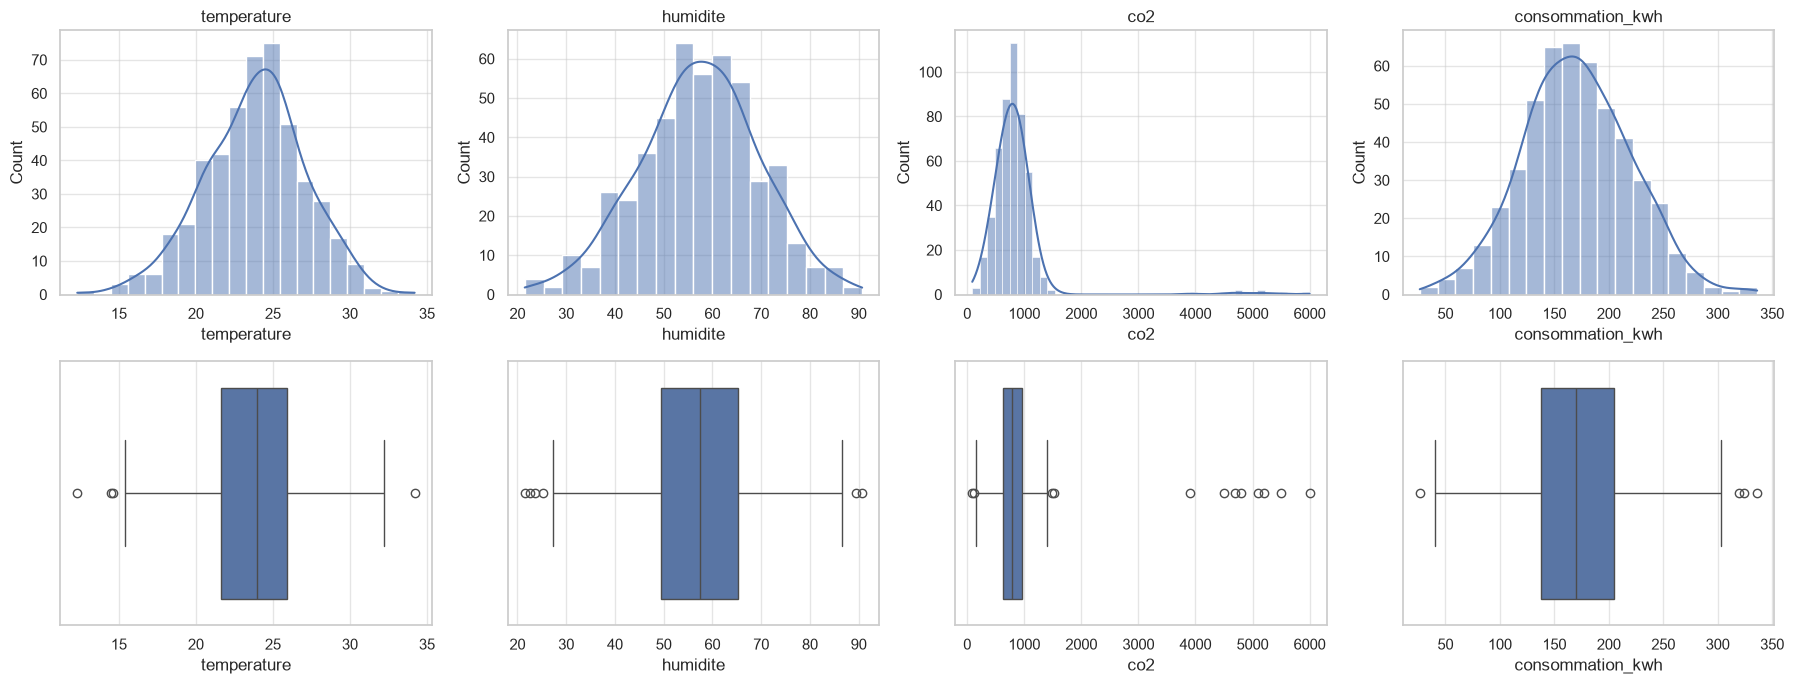

,min,median,max,std,skew
temperature,12.3,24.0,34.2,3.27,-0.20
humidite,21.5,57.4,90.7,12.25,-0.12
co2,89.0,786.0,6000.0,585.51,5.98
consommation_kwh,26.4,169.9,336.2,49.83,0.11


In [60]:
vars_visu = ['temperature', 'humidite', 'co2', 'consommation_kwh']
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for j, v in enumerate(vars_visu):
    sns.histplot(df_nettoye[v], kde=True, ax=axes[0, j])            # forme de la distribution
    axes[0, j].set_title(v)
    sns.boxplot(x=df_nettoye[v], ax=axes[1, j])                      # médiane, quartiles, points isolés
plt.tight_layout()
plt.show()

df_nettoye[vars_visu].agg(['min', 'median', 'max', 'std', 'skew']).T.round(2)

#### Réponse / Interprétation
**a) Formes.** Température, humidité et consommation sont à peu près symétriques, en cloche (asymétrie de −0,20, −0,12 et +0,11). Le CO₂ est très asymétrique à droite (asymétrie ≈ 6) : une masse autour de 790 ppm et une longue queue jusqu'à 6 000.

**b) Dispersion.** Rapportée à la moyenne : environ 14 % pour la température, 21 % pour l'humidité, 29 % pour la consommation et près de 70 % pour le CO₂, dont l'écart-type est gonflé par la queue.

**c) Extrêmes.** Après nettoyage, tout est plausible pour la température (12,3 à 34,2 °C), l'humidité (21,5 à 90,7 %) et la consommation (26,4 à 336,2 kWh). Le CO₂ va de 89 à 6 000 ppm.

**d) Valeurs potentiellement aberrantes.** Surtout le CO₂ : **8 mesures entre 3 900 et 6 000 ppm**, isolées (la valeur suivante est 1 519 ppm). S'y ajoutent quelques points en marge des boîtes pour les autres variables, plausibles, et 3 CO₂ très bas (89, 120 et 160 ppm), inférieurs à l'air extérieur (environ 420 ppm) : suspects, sans être impossibles (dérive de capteur).

### 16. Quelle stratégie pour les valeurs aberrantes ?
#### Objectif
Décider quoi faire des valeurs extrêmes qui restent.
#### Pourquoi ?
Une valeur aberrante peut être une **erreur** (à écarter) ou une **vraie anomalie** (à garder : détecter les anomalies est justement le but du projet).
#### Méthode
Chiffrer les valeurs hors bornes IQR par variable, puis mesurer leur effet sur l'écart-type (donc sur `StandardScaler`).
#### Code et résultat

In [61]:
def bornes_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr          # bornes de Tukey

lignes = []
for v in variables_numeriques:
    s = df_nettoye[v].dropna()
    bas, haut = bornes_iqr(s)
    hors = (s < bas) | (s > haut)
    lignes.append({'variable': v, 'borne_basse': bas, 'borne_haute': haut, 'nb_hors_bornes': int(hors.sum()),
                   'pct': hors.mean() * 100, 'std': s.std(), 'std_apres_clip': s.clip(bas, haut).std()})
pd.DataFrame(lignes).set_index('variable').round(2)

,borne_basse,borne_haute,nb_hors_bornes,pct,std,std_apres_clip
variable,,,,,,
temperature,15.15,32.35,4,0.83,3.27,3.23
humidite,25.80,89.00,6,1.25,12.25,12.18
co2,132.00,1444.00,12,2.43,585.51,251.88
occupation,-21.50,110.50,4,0.82,24.47,24.38
consommation_kwh,36.60,305.40,4,0.81,49.83,49.39


#### Réponse / Interprétation
Trois règles :
1. **Erreur physique impossible** → `NaN`, puis imputation. C'est fait en Q12 (humidité hors 0–100, température hors 0–50, valeurs négatives).
2. **Extrême plausible** (CO₂ élevé, occupation > 100, forte consommation) → **on ne supprime pas** : ce peut être une vraie anomalie, et détecter les situations anormales est justement l'objectif du projet. On limite plutôt leur influence : `RobustScaler` (médiane et IQR), plafonnement (`clip`) aux bornes IQR, transformation logarithmique du CO₂, ou modèle insensible aux extrêmes (arbres).
3. **Vérifier à la source** quand c'est possible (ici, les 8 mesures de CO₂ au-dessus de 3 900 ppm).

Le tableau montre l'enjeu : l'IQR ne signale que 0,8 à 2,4 % des lignes par variable, mais pour le CO₂ le plafonnement fait chuter l'écart-type de **586 à 252** : `StandardScaler` serait dominé par 12 mesures. Pour les quatre autres variables, l'écart-type ne bouge presque pas : rien à faire. *Les bornes du tableau sont calculées sur tout le dataset pour explorer ; si on plafonne pour de bon, elles seront apprises sur le train.*

### 17. Fréquences des catégories
#### Objectif
Afficher la fréquence des bâtiments, types, modes, états et classes d'alerte.
#### Pourquoi ?
Repérer les catégories rares ou dominantes avant l'encodage.
#### Méthode
Une fonction `frequences` (tableau + diagramme en barres) appliquée à chaque variable.
#### Code et résultat

In [62]:
def frequences(colonne):
    eff = df_nettoye[colonne].value_counts(dropna=False)             # dropna=False : compter aussi les NaN
    tab = pd.DataFrame({'effectif': eff, 'pourcentage': (eff / len(df_nettoye) * 100).round(1)})
    display(tab)
    plt.figure(figsize=(6, 2.8))
    sns.countplot(data=df_nettoye, x=colonne, order=tab.index.dropna())
    plt.title(colonne)
    plt.show()

#### 17.a Bâtiments

,effectif,pourcentage
batiment,,
b1,92,18.4
b5,65,13.0
b7,64,12.8
b2,60,12.0
b4,58,11.6
b3,57,11.4
b8,53,10.6
b6,51,10.2


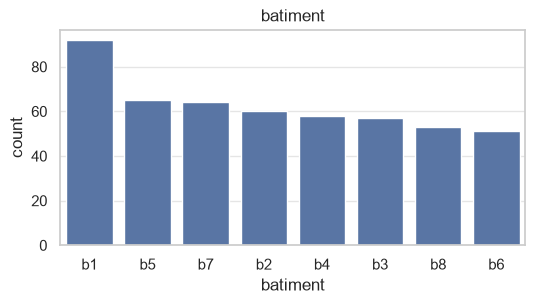

In [63]:
frequences('batiment')

#### 17.b Types de bâtiments

,effectif,pourcentage
type_batiment,,
bureau,214,42.8
centre commercial,65,13.0
école,60,12.0
hôpital,57,11.4
entrepôt,53,10.6
université,51,10.2


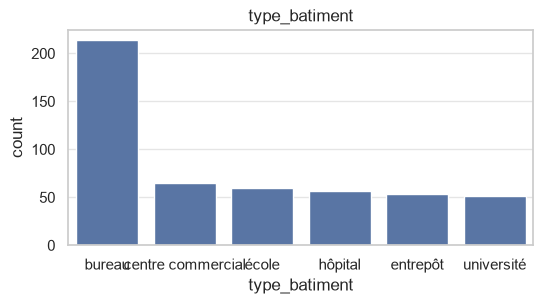

In [64]:
frequences('type_batiment')

#### 17.c Modes de climatisation

,effectif,pourcentage
mode_climatisation,,
normal,268,53.6
eco,130,26.0
boost,97,19.4
NaN,5,1.0


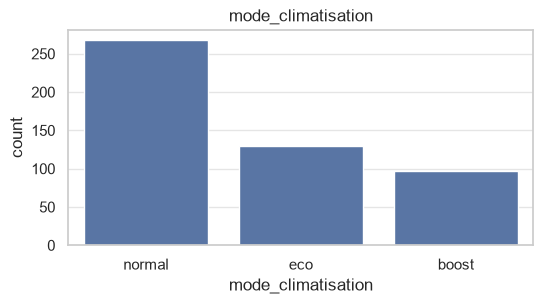

In [65]:
frequences('mode_climatisation')

#### 17.d États du système

,effectif,pourcentage
etat_systeme,,
normal,436,87.2
alerte,52,10.4
panne,12,2.4


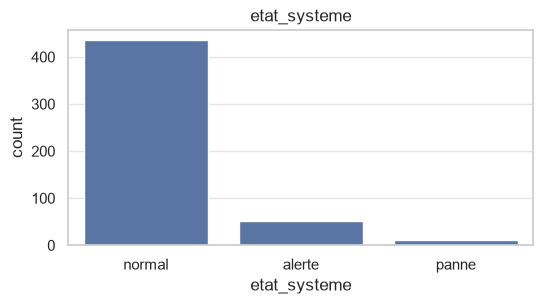

In [66]:
frequences('etat_systeme')

#### 17.e Classes « alerte »

,effectif,pourcentage
alerte,,
non,356,71.2
oui,144,28.8


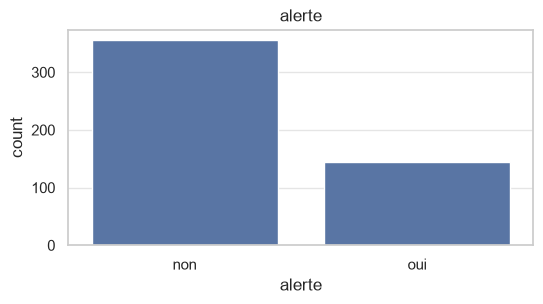

In [67]:
frequences('alerte')

#### Réponse / Interprétation
- **Bâtiments** : B1 est le plus représenté (18,4 %), les autres pèsent 10 à 13 %.
- **Types** : « bureau » domine (42,8 %) parce que 3 bâtiments sur 8 (B1, B4, B7) sont des bureaux ; les 5 autres types pèsent 10 à 13 % chacun.
- **Modes** : normal 53,6 %, eco 26 %, boost 19,4 % (et 5 manquants).
- **États** : 87,2 % normal, 10,4 % alerte et seulement **12 lignes « panne »** (2,4 %) : c'est une **catégorie rare**, à surveiller à l'encodage et au découpage.
- **Alerte** : 71,2 % « non » contre 28,8 % « oui » (voir Q18).

### 18. Y a-t-il un déséquilibre des classes sur « alerte » ?
#### Objectif
Mesurer le poids de chaque classe de la cible.
#### Pourquoi ?
Sur une cible déséquilibrée, l'exactitude (accuracy) est trompeuse : un modèle qui répond toujours « non » paraît bon.
#### Méthode
Rapport entre classes et exactitude d’un modèle « toujours majoritaire ».
#### Code et résultat

In [68]:
comptage = df_nettoye['alerte'].value_counts()
print(comptage.to_dict())
print(f'Rapport majoritaire/minoritaire : {comptage.max() / comptage.min():.2f} : 1')
print(f'Exactitude d’un modèle naïf « toujours {comptage.idxmax()} » : {comptage.max() / comptage.sum() * 100:.1f} %')

{'non': 356, 'oui': 144}
Rapport majoritaire/minoritaire : 2.47 : 1
Exactitude d’un modèle naïf « toujours non » : 71.2 %


#### Réponse / Interprétation
**Oui, un déséquilibre modéré** : 356 « non » contre 144 « oui » (71,2 % / 28,8 %), soit 2,47 contre 1. Un modèle qui répondrait toujours « non » aurait 71,2 % d'exactitude sans rien détecter : l'accuracy est trompeuse ici.

Conséquences : découpage **stratifié** (Partie 3), métriques adaptées (rappel, précision, F1, AUC-PR) et, si besoin, `class_weight='balanced'` ou rééchantillonnage **sur le train uniquement**. Le déséquilibre reste assez faible pour ne pas imposer de rééchantillonnage systématique.

### 19. Corrélation des variables numériques

#### 19.a. Matrice de corrélation (seaborn)
#### Objectif
Visualiser les corrélations entre variables numériques.
#### Pourquoi ?
Repérer les redondances (variables très liées) et les liens utiles.
#### Méthode
`corr()` (Pearson, calculé par paires en ignorant les `NaN`) puis `sns.heatmap` centrée sur 0.
#### Code et résultat

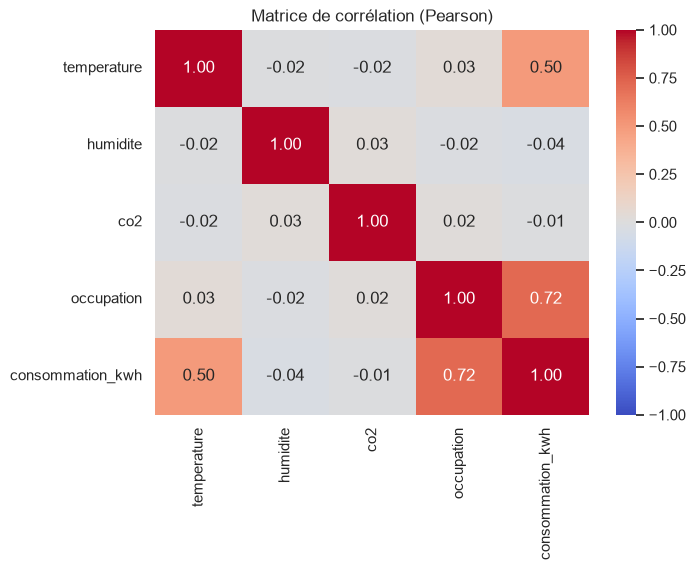

In [69]:
corr = df_nettoye[variables_numeriques].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Matrice de corrélation (Pearson)')
plt.show()

#### Réponse / Interprétation
Seules deux zones ressortent : `occupation` / `consommation_kwh` (r = 0,72) et `temperature` / `consommation_kwh` (r = 0,50). Tout le reste est proche de 0.

#### 19.b. Corrélations positives, négatives et faibles
#### Objectif
Classer chaque paire de variables.
#### Pourquoi ?
Une lecture chiffrée évite de se fier à la seule couleur de la carte.
#### Méthode
Triangle supérieur de la matrice, tri par |r|, classement : |r| ≥ 0,3 modérée ; |r| < 0,1 quasi nulle.
#### Code et résultat

In [70]:
paires = pd.DataFrame([{'paire': f'{a} / {b}', 'r': corr.loc[a, b]}
                        for a, b in combinations(corr.columns, 2)]).set_index('paire')   # chaque paire une seule fois
paires['|r|'] = paires['r'].abs()
paires['lecture'] = np.select(
    [paires['r'] >= 0.3, paires['r'] <= -0.3, paires['|r|'] < 0.1],
    ['positive', 'négative', 'quasi nulle'], default='faible')
paires.sort_values('|r|', ascending=False).round(3)

,r,|r|,lecture
paire,,,
occupation / consommation_kwh,0.718,0.718,positive
temperature / consommation_kwh,0.499,0.499,positive
humidite / consommation_kwh,-0.036,0.036,quasi nulle
temperature / occupation,0.031,0.031,quasi nulle
humidite / co2,0.029,0.029,quasi nulle
temperature / co2,-0.023,0.023,quasi nulle
humidite / occupation,-0.021,0.021,quasi nulle
co2 / occupation,0.018,0.018,quasi nulle
temperature / humidite,-0.015,0.015,quasi nulle


#### Réponse / Interprétation
- **Positives** : occupation / consommation (0,72, forte : plus de monde, plus d'énergie) et température / consommation (0,50, modérée).
- **Négatives** : aucune notable. La plus négative, humidité / consommation, vaut −0,04 : quasi nulle.
- **Faibles ou quasi nulles** : 8 paires sur 10, dont tout ce qui touche le CO₂ (|r| ≤ 0,03) : le CO₂ varie indépendamment des autres mesures.

Conséquences : pas de redondance forte (maximum 0,72), donc on garde toutes les variables ; `consommation_kwh` est la mieux expliquée par les autres mesures, ce qui compte si on veut la prédire. Attention : corrélation n'est pas causalité, et Pearson ne mesure que les liens linéaires.

# Partie 2 – Séparation X / y

### 2.1. Définir « alerte » comme cible y
#### Objectif
Isoler la variable à prédire.
#### Pourquoi ?
Scikit-learn attend une cible numérique. `alerte` est binaire : `oui` -> 1 (situation anormale), `non` -> 0.
#### Méthode
Dictionnaire explicite `{non: 0, oui: 1}` plutôt qu’un encodeur automatique, pour maîtriser le sens de 0/1.
#### Code et résultat

In [71]:
y = df_nettoye['alerte'].map({'non': 0, 'oui': 1})     # correspondance explicite
assert y.notna().all(), 'modalité inattendue dans alerte'
y.name = 'alerte'
print(y.value_counts().rename({0: 'non (0)', 1: 'oui (1)'}).to_dict())

{'non (0)': 356, 'oui (1)': 144}


#### Réponse / Interprétation
`y` est binaire : **356 zéros** (non) et **144 uns** (oui). Le codage explicite garantit que 1 = alerte, la classe qui nous intéresse : rappel et précision seront mesurés par rapport à elle.

#### 2.2. Trouver des variables explicatives X pertinentes
#### Objectif
Choisir les colonnes qui peuvent expliquer `alerte`.
#### Pourquoi ?
Une bonne variable explicative est disponible **avant** l'événement, liée physiquement à la cible et sans fuite (elle ne doit pas « contenir » la réponse).
#### Méthode
Étape 1 : mesurer le lien de chaque variable avec la cible (indicatif). Étape 2 : décider par la logique métier et retirer identifiants, cible et colonnes inutilisables.
#### Code et résultat

In [72]:
# Étape 1 — liens avec la cible (descriptif : on ne sélectionne pas sur ces seuls chiffres, voir réponse)
mesures = pd.DataFrame({
    'corr. avec alerte': df_nettoye[variables_numeriques].corrwith(y),
    'médiane si non': df_nettoye.loc[y == 0, variables_numeriques].median(),
    'médiane si oui': df_nettoye.loc[y == 1, variables_numeriques].median(),
})
display(mesures.round(3))

liens = {}
for c in [v for v in variables_categorielles if v != 'alerte']:
    ct = pd.crosstab(df_nettoye[c], y)
    chi2, p, _, _ = chi2_contingency(ct)
    liens[c] = {"V de Cramér": np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1))), 'p-value': p}
display(pd.DataFrame(liens).T.round(3))

,corr. avec alerte,médiane si non,médiane si oui
temperature,-0.050,24.2,23.6
humidite,0.056,57.1,57.9
co2,0.303,689.0,1038.0
occupation,0.054,44.0,50.0
consommation_kwh,0.003,170.5,168.7


,V de Cramér,p-value
batiment,0.118,0.438
type_batiment,0.086,0.599
zone,0.034,0.900
mode_climatisation,0.037,0.710
etat_systeme,0.016,0.940
jour_semaine,0.107,0.450


#### Réponse / Interprétation
Lecture : **seul le CO₂ se détache** (r = 0,30 ; médiane de 1 038 ppm en cas d'alerte contre 689 sinon). Les autres mesures ont |r| ≤ 0,06 et aucune variable catégorielle n'est significativement liée à l'alerte (V de Cramér ≤ 0,12, p > 0,4). *Ces chiffres sont descriptifs : voir la décision ci-dessous pour savoir pourquoi on ne s'en sert pas pour éliminer des variables.*

#### Décision
Étape 2 — retirer ce qui ne doit pas entrer dans X, puis construire X.

In [73]:
colonnes_exclues = ['alerte',      # la cible elle-même
                    'id_mesure',   # identifiant : aucun sens physique
                    'date']        # horodatage brut inutilisable tel quel (jour_semaine en garde l'essentiel)
X = df_nettoye.drop(columns=colonnes_exclues)

print('Variables explicatives retenues :', X.columns.tolist())
print('Numériques   :', X.select_dtypes(include='number').columns.tolist())
print('Catégorielles:', X.select_dtypes(exclude='number').columns.tolist())

Variables explicatives retenues : ['batiment', 'type_batiment', 'zone', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh', 'mode_climatisation', 'etat_systeme', 'jour_semaine']
Numériques   : ['temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']
Catégorielles: ['batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine']


#### Réponse / Interprétation
**Retenues (11 variables)** : les 5 mesures numériques et 6 variables catégorielles (`batiment`, `type_batiment`, `zone`, `mode_climatisation`, `etat_systeme`, `jour_semaine`).

**Exclues (3)** : `alerte` (la cible), `id_mesure` (identifiant sans sens physique) et `date` (horodatage brut inutilisable tel quel ; son apport principal, le jour de la semaine, est déjà dans `jour_semaine`).

Pourquoi ne pas trier davantage à partir du tableau ?
- **Seul le CO₂ montre un lien net avec l'alerte** ; toutes les autres variables ont un lien individuel quasi nul.
- Un lien individuel faible n'exclut pas une utilité en combinaison. Et **choisir les variables sur tout le dataset avant le découpage** ferait fuiter de l'information du test vers le train. Le tri fin se fera plus tard, sur le train seul (importance des variables, régularisation).
- **Pas de fuite de cible** : `etat_systeme` a une modalité « alerte » qui pourrait sembler être un proxy de la cible, mais son lien est nul (V = 0,016 ; p = 0,94). Aucune variable retenue ne reproduit la cible (liens tous ≤ 0,30).
- **Redondance connue** : `type_batiment` est déterminé par `batiment`. On garde les deux pour l'instant ; la Partie 4 décidera de leur encodage.

### 2.3. Afficher les cinq premières lignes de X et de y
#### Objectif
Contrôler visuellement X et y.
#### Pourquoi ?
S’assurer que X ne contient plus la cible et que X et y sont alignés ligne à ligne.
#### Méthode
`head()` sur chacun, puis contrôles de forme, d’index et de valeurs manquantes.
#### Code et résultat

In [74]:
display(X.head())
display(y.head())
print('X :', X.shape, '| y :', y.shape, '| index identiques :', X.index.equals(y.index))
print('La cible est absente de X :', 'alerte' not in X.columns)
print('Manquantes restantes dans X (imputées plus tard, dans le pipeline) :', X.isna().sum()[lambda s: s > 0].to_dict())

,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine
0,b8,entrepôt,a,23.0,40.0,851.0,26.0,138.4,eco,normal,jeudi
1,b7,bureau,d,28.0,69.0,538.0,0.0,170.2,eco,normal,lundi
2,b5,centre commercial,b,19.5,52.3,1198.0,64.0,149.8,normal,normal,dimanche
3,b6,université,d,20.0,58.4,1014.0,30.0,141.6,normal,normal,dimanche
4,b7,bureau,d,26.8,70.5,628.0,42.0,228.3,normal,normal,jeudi


0    0
1    0
2    1
3    0
4    0
Name: alerte, dtype: int64

X : (500, 11) | y : (500,) | index identiques : True
La cible est absente de X : True
Manquantes restantes dans X (imputées plus tard, dans le pipeline) : {'temperature': 18, 'humidite': 20, 'co2': 7, 'occupation': 11, 'consommation_kwh': 9, 'mode_climatisation': 5}


#### Réponse / Interprétation
X fait **500 lignes × 11 colonnes**, y **500 valeurs**, avec le même index, et la cible est absente de X. Les cinq premières lignes concordent : la seule alerte (index 2, y = 1) est aussi la ligne au CO₂ le plus élevé (1 198 ppm). Il reste **70 valeurs manquantes** dans X (18 températures, 20 humidités, 7 CO₂, 11 occupations, 9 consommations et 5 modes) : elles seront imputées dans le pipeline (Partie 6), après le découpage.

# Partie 3 – Découpage Train/Test

### 3. Diviser X en un ensemble d'entraînement et un ensemble de test
#### Objectif
Séparer X et y en deux ensembles distincts : **train** (80 %) pour apprendre et **test** (20 %) pour évaluer.
#### Pourquoi ?
Évaluer un modèle sur les données qui ont servi à l'entraîner mesure sa mémoire, pas sa capacité à généraliser. Le jeu de test simule des données jamais vues.
Le découpage se fait **avant** l'imputation, l'encodage et la mise à l'échelle : ces étapes apprendront leurs paramètres (médiane, modalités, moyenne, écart-type) sur le train uniquement, sinon des informations du test fuiteraient dans l'entraînement.
#### Méthode
`train_test_split` avec les trois conditions demandées :
- `test_size=0.20` : 20 % des lignes vont au test ;
- `random_state=42` : graine fixe, donc le même découpage à chaque exécution ;
- `stratify=y` : la proportion de « oui » / « non » est la même dans train, dans test et dans les données d'origine.


In [77]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42          # graine fixe : le même découpage à chaque exécution

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20 % des lignes pour le test
    random_state=RANDOM_STATE,
    stratify=y,            # garde la même proportion de oui/non dans train et test
)

print(f'X_train : {X_train.shape} | X_test : {X_test.shape}')
print(f'y_train : {y_train.shape} | y_test : {y_test.shape}')

# 1) part de chaque ensemble
print(f'\nPart du test : {len(X_test) / len(X):.0%}')

# 2) proportion de la classe « oui » (1) dans le jeu d'origine, le train et le test
proportions = pd.DataFrame({
    'lignes': [len(y), len(y_train), len(y_test)],
    'alertes (oui)': [y.sum(), y_train.sum(), y_test.sum()],
    '% oui': [y.mean() * 100, y_train.mean() * 100, y_test.mean() * 100],
}, index=['origine', 'train', 'test']).round(1)
display(proportions)

# 3) aucune ligne commune entre train et test
print('Lignes communes train/test :', len(set(X_train.index) & set(X_test.index)))

# 4) reproductibilité : un second découpage avec la même graine donne exactement le même résultat
X_train2, X_test2, _, _ = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print('Découpage reproductible :', X_train.index.equals(X_train2.index) and X_test.index.equals(X_test2.index))

X_train : (400, 11) | X_test : (100, 11)
y_train : (400,) | y_test : (100,)

Part du test : 20%


,lignes,alertes (oui),% oui
origine,500,144,28.8
train,400,115,28.7
test,100,29,29.0


Lignes communes train/test : 0
Découpage reproductible : True


- **20 % pour le test** : 500 lignes deviennent **400 en train et 100 en test**.
- **Mêmes proportions de classes** : la part d'alertes est de 28,8 % dans les données d'origine, 28,75 % dans le train et 29 % dans le test. Sans `stratify`, sur seulement 100 lignes de test, le hasard pourrait déséquilibrer nettement ce taux d'un tirage à l'autre et fausser l'évaluation.
- **Reproductibilité** : avec `random_state=42`, un second découpage donne exactement les mêmes lignes (`True`). La valeur 42 est arbitraire, l'important est qu'elle soit fixée.
- **Ensembles distincts** : aucune ligne n'est commune au train et au test. Les doublons ayant été supprimés en Q14, une même mesure ne peut pas se retrouver des deux côtés, ce qui aurait gonflé artificiellement le score.
- **À retenir pour la suite** : `X_train` contient encore des valeurs manquantes, elles seront imputées dans le pipeline (Partie 6) avec des statistiques calculées sur `X_train` seul. Les mesures étant horodatées, un découpage chronologique serait plus réaliste pour prédire l'avenir, mais l'énoncé demande ici un découpage aléatoire stratifié.
-